# B 파트 EDA — daily, price(시간외), earnings, analyst (팀 데이터)

- 데이터: **train 전용 원본 `dataset_train/`** (팀 공용 `work/common/make_split_data.py` 로 생성, zip `dataset_train_until_2026-02-12.zip`).
  val(2026-03~05)·embargo·최종 테스트는 파일에 아예 없음.
- **EDA 구간 = train 전체** (대상일 2024-08-14 ~ 2026-02-12, 376일). 피처는 `cache/b_features_train.parquet`.
  원본 표를 볼 때도 마지막 대상일의 cutoff(09:30) 까지만 읽는다.
- 순서
  1. 표별 데이터 점검 (품질)
  2. 기간별 label 분포
  3. 피처 신호: 5분위 · 날짜를 섞은 상관 · **날짜별 순위 상관(IC)** · 5개 기간 안정성
  4. 특수한 날: 실적 발표 직후, 주말·휴장 다음날
  5. V1 재확인 (기준은 결과 보기 전에 정함)
  6. 발표용 그림

피처는 `work/b/cache/b_features_train.parquet` (`build_cache.py` → `work/common/make_split_data.py`).

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path.cwd()
while not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "work" / "b"))
warnings.filterwarnings("ignore")
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 120)

from src import Dataset, START
from src.data import CUTOFF
from features_b import (B_FEATURES, B_FEATURES_V1, B_DAILY, B_PRICE, B_EARN, B_ANALYST, B_CAL,
                        B_V1_GAP, B_V1_VOL, B_V1_MOM, B_V1_MKT)
ds = Dataset(folder=ROOT / "dataset_train")          # train 전용 원본 (val 없음)
b = pd.read_parquet(ROOT / "work/b/cache/b_features_train.parquet")
b["label"] = b.label.astype(int)
b["absret"] = b.ret_pct.abs()
b["up"] = (b.label >= 3).astype(int)
b["big"] = b.label.isin([0, 4]).astype(int)

tr = b.copy()                                         # train 전체
EDA_END = tr.target.max()                             # 이 대상일의 cutoff 까지만 원본 표를 읽음
UNTIL = EDA_END + CUTOFF
print(ds)
print(f"EDA 구간: {len(tr):,}행, 기준일 {tr.date.nunique()}일, 대상일 {tr.target.min():%Y-%m-%d} ~ {EDA_END:%Y-%m-%d}")
print(f"원본 표는 [{START:%Y-%m-%d}, {UNTIL}) 만 읽음")

<Dataset 50종목 기준일 2024-08-13~2026-02-11 376일 (일봉 2023-10-23~2026-02-12)>
EDA 구간: 18,800행, 기준일 376일, 대상일 2024-08-14 ~ 2026-02-12
원본 표는 [2024-08-13, 2026-02-12 09:30:00) 만 읽음


## 1. 표별 데이터 점검 (EDA 구간)
### 1-1. daily

In [2]:
d = ds.table("daily", since=START, until=UNTIL)
per_date = d.groupby("date_et").symbol.nunique()
print("거래일 수", len(per_date), "| 날짜별 종목 수 분포", per_date.value_counts().to_dict())
print("ret 결측 행", int(d.ret.isna().sum()))
print("캐시에서 ret1 NaN 비율:", round(tr.ret1.isna().mean() * 100, 3), "%")
big = d[d.ret.abs() > 0.2][["symbol", "date_et", "ret"]]
print(f"|ret| > 20% 일봉 {len(big)}건"); print(big.assign(ret=big.ret.round(3)).to_string(index=False))

거래일 수 376 | 날짜별 종목 수 분포 {50: 376}
ret 결측 행 0
캐시에서 ret1 NaN 비율: 0.0 %
|ret| > 20% 일봉 5건
symbol    date_et   ret
  AVGO 2024-12-13 0.243
   AMD 2025-04-09 0.237
  ORCL 2025-09-10 0.359
  INTC 2025-09-18 0.228
   AMD 2025-10-06 0.237


### 1-2. price (시간외)
시간외 봉은 volume 이 0 인지, 봉 개수 분포, cutoff 전 마지막 pre 봉 시각.

In [3]:
for c in ["post_n", "pre_n", "ext_n"]:
    print(c, tr[c].value_counts().sort_index().to_dict())
print("시간외 봉이 하나도 없는 (날짜, 종목):", round((tr.ext_n == 0).mean() * 100, 2), "%")
print("  그 대상일:", {f"{k:%Y-%m-%d}": v for k, v in tr[tr.ext_n == 0].groupby("target").size().items()})
print("gap_days 별 평균 봉 수\n", tr.groupby("gap_days")[["post_n", "pre_n", "ext_n"]].mean().round(2))

p = ds.table("price", since=START, until=UNTIL, columns=["symbol", "datetime", "session", "volume", "known_at"])
ext = p[p.session != "regular"]
reg_n = p[p.session == "regular"].groupby(p.datetime.dt.normalize()).size()
print("정규장 봉이 300개 미만인 날 (50종목 × 7봉 = 350 이 정상, 조기 폐장은 297~299):", {f"{k:%Y-%m-%d}": int(v) for k, v in reg_n[reg_n < 300].items()})
print("시간외 봉 volume: 0 인 비율", round((ext.volume == 0).mean() * 100, 2), "%, 합", int(ext.volume.sum()))
pre = p[p.session == "pre"].assign(day=lambda x: x.datetime.dt.normalize())
hm = pre.known_at.dt.hour * 60 + pre.known_at.dt.minute
last_pre = pre[hm < 9 * 60 + 30].groupby(["day", "symbol"]).known_at.max().dt.strftime("%H:%M")
print("cutoff 전 마지막 pre 봉 known_at (%)\n", (last_pre.value_counts(normalize=True) * 100).round(2).head(5).to_dict())

post_n {0.0: 53, 1.0: 261, 2.0: 230, 3.0: 7709, 4.0: 10547}
pre_n {0.0: 71, 1.0: 103, 2.0: 350, 3.0: 668, 4.0: 1735, 5.0: 15873}
ext_n {0.0: 50, 2.0: 23, 3.0: 25, 4.0: 94, 5.0: 297, 6.0: 706, 7.0: 1177, 8.0: 7161, 9.0: 9267}
시간외 봉이 하나도 없는 (날짜, 종목): 0.27 %
  그 대상일: {'2026-02-02': 50}
gap_days 별 평균 봉 수
           post_n  pre_n  ext_n
gap_days                      
1.0         3.57   4.74   8.31
2.0         2.58   4.73   7.31
3.0         3.43   4.74   8.17
4.0         3.14   4.82   7.96


정규장 봉이 300개 미만인 날 (50종목 × 7봉 = 350 이 정상, 조기 폐장은 297~299): {'2024-11-29': 297, '2024-12-24': 299, '2025-07-03': 299, '2025-12-24': 298, '2026-01-30': 67, '2026-02-02': 150}
시간외 봉 volume: 0 인 비율 100.0 %, 합 5405973


cutoff 전 마지막 pre 봉 known_at (%)
 {'09:00': 99.52, '06:00': 0.23, '08:00': 0.2, '05:00': 0.04, '07:00': 0.02}


### 1-3. earnings

In [4]:
e = ds.table("earnings", since=START, until=UNTIL)
hm = e.known_at.dt.hour * 60 + e.known_at.dt.minute
e["when"] = np.select([hm >= 16 * 60, hm < 9 * 60 + 30], ["장 마감 후", "개장 전"], "장중")
print("발표 시각:", e.when.value_counts().to_dict(), "|", e.known_at.dt.strftime("%H:%M").value_counts().head(6).to_dict())
print("기준일 16:00~cutoff 사이 발표가 있는 (날짜, 종목):", int(tr.earn_now.sum()), f"({tr.earn_now.mean() * 100:.2f}%)")
print("surprise_pct 분위:", e.surprise_pct.quantile([.01, .05, .5, .95, .99]).round(1).to_dict(),
      "| min/max", round(e.surprise_pct.min(), 1), round(e.surprise_pct.max(), 1), "| eps_estimate 결측", int(e.eps_estimate.isna().sum()))
print("|surprise| > 100%:", e[e.surprise_pct.abs() > 100].symbol.value_counts().to_dict())

발표 시각: {'개장 전': 168, '장 마감 후': 129, '장중': 1} | {'16:00': 129, '06:00': 87, '07:00': 68, '08:00': 13, '10:00': 1}
기준일 16:00~cutoff 사이 발표가 있는 (날짜, 종목): 297 (1.58%)
surprise_pct 분위: {0.01: -87.2, 0.05: -7.2, 0.5: 4.7, 0.95: 38.7, 0.99: 651.5} | min/max -1533.5 3162.4 | eps_estimate 결측 1
|surprise| > 100%: {'INTC': 4, 'UBER': 3, 'PLD': 2, 'BA': 2}


### 1-4. analyst

In [5]:
a = ds.table("analyst", since=START, until=UNTIL)
print("action:", a.action.value_counts().to_dict())
print("target_action:", a.target_action.value_counts(dropna=False).to_dict())
print(f"target_prior 결측 {a.target_prior.isna().mean() * 100:.1f}%, 0 이하 {(a.target_prior <= 0).mean() * 100:.2f}%, "
      f"target_current 결측 {a.target_current.isna().mean() * 100:.1f}%")
print("기준일 16:00~cutoff 사이 의견이 있는 (날짜, 종목):", f"{(tr.an_now_n > 0).mean() * 100:.2f}%")
cov = tr.groupby("symbol").an_n30.median().sort_values()
print("종목별 30일 의견 수 중앙값: 하위", cov.head(3).to_dict(), "상위", cov.tail(3).to_dict())

action: {'main': 3587, 'reit': 464, 'up': 182, 'init': 145, 'down': 136}
target_action: {'Raises': 2634, 'Lowers': 1031, 'Maintains': 548, 'Announces': 194, nan: 97, 'Adjusts': 10}
target_prior 결측 6.5%, 0 이하 0.00%, target_current 결측 2.1%
기준일 16:00~cutoff 사이 의견이 있는 (날짜, 종목): 5.90%
종목별 30일 의견 수 중앙값: 하위 {'BRK-B': 0.0, 'WELL': 0.0, 'LIN': 1.0} 상위 {'WMT': 8.0, 'AMD': 9.0, 'AMZN': 10.0}


## 2. 기간별 label 분포 (EDA 구간)
급등락 비율이 기간에 따라 얼마나 바뀌는지. 팀원 확인: 올해(2026) 20% 안팎으로 상승 — train 에 들어간 2026-01·02 에서 확인 (val 3~5월은 안 봄).

In [6]:
m = tr.assign(month=tr.target.dt.to_period("M")).groupby("month")
dist = pd.DataFrame({"n": m.size(), "급등락%": m.big.mean() * 100, "보합%": m.label.apply(lambda s: (s == 2).mean() * 100),
                     "|ret| 평균": m.absret.mean(), "상승%": m.up.mean() * 100}).round(1)
print(dist.to_string())
print("\n전체 label 분포(%):", (tr.label.value_counts(normalize=True).sort_index() * 100).round(1).to_dict())

            n  급등락%   보합%  |ret| 평균   상승%
month                                    
2024-08   650   6.9  42.6       1.0  40.2
2024-09  1000  11.0  35.3       1.2  36.7
2024-10  1150   9.5  38.9       1.1  30.3
2024-11  1000  13.9  34.6       1.3  38.2
2024-12  1050   8.9  40.2       1.2  24.2
2025-01  1000  13.9  33.5       1.4  40.8
2025-02   950  13.9  30.1       1.4  38.2
2025-03  1050  20.8  28.1       1.6  33.8
2025-04  1050  30.0  24.2       2.4  40.9
2025-05  1050  14.1  34.9       1.3  36.1
2025-06  1000   8.9  37.3       1.1  37.2
2025-07  1100   9.5  36.5       1.2  33.1
2025-08  1050  11.0  41.0       1.2  35.6
2025-09  1050   8.7  38.5       1.2  32.4
2025-10  1150  14.3  33.0       1.4  34.3
2025-11   950  15.2  32.4       1.4  37.1
2025-12  1100   9.0  41.7       1.1  29.5
2026-01  1000  17.0  32.5       1.5  35.8
2026-02   450  30.0  20.4       2.1  46.2

전체 label 분포(%): {0: 6.6, 1: 23.3, 2: 34.9, 3: 28.2, 4: 7.0}


## 3. 피처 신호 (EDA 구간)
- `dir` = Spearman(f, ret), `mag` = Spearman(f, |ret|) 또는 Spearman(|f|, |ret|) 중 큰 쪽 — 날짜를 섞어서 계산
- `dir_IC`, `mag_IC` = **날짜별** 종목 간 Spearman 의 평균. "같은 날 어느 종목이 더 오르나"만 봄.
  `t` = 평균 / 표준편차 × √일수 (독립 가정 근사), `hit` = IC 부호가 평균과 같은 날 비율
- 기간 안정성: EDA 구간을 기준일 수로 5등분, 기간별 날짜 IC 평균의 부호가 전체와 같은 기간 수
- 날짜 안에서 값이 같은 피처(mkt_*, gap_days, dow)는 날짜별 IC 가 없음 → 섞은 상관으로만 보고, 실질 표본은 기준일 수

In [7]:
def sp(x, y):
    ok = x.notna() & y.notna()
    return x[ok].corr(y[ok], method="spearman") if ok.sum() > 50 else np.nan

def daily_ic(df, x, y):
    r = df[["date", x, y]].dropna()
    rx, ry = r.groupby("date")[x].rank(), r.groupby("date")[y].rank()
    t = pd.DataFrame({"date": r.date, "a": rx, "b": ry})
    return t.groupby("date").apply(lambda g: g.a.corr(g.b) if g.a.nunique() > 1 else np.nan, include_groups=False).dropna()

dates = np.sort(tr.date.unique())
per = pd.Series(pd.qcut(np.arange(len(dates)), 5, labels=False), index=dates)
tr["period"] = tr.date.map(per)
print("5개 기간:", tr.groupby("period").target.agg(["min", "max"]).apply(lambda r: f"{r['min']:%Y-%m-%d}~{r['max']:%Y-%m-%d}", axis=1).to_dict())

rows = {}
for f in B_FEATURES:
    if tr[f].nunique() < 2:
        continue
    mag_raw, mag_abs = sp(tr[f], tr.absret), sp(tr[f].abs(), tr.absret)
    kind = "raw" if abs(mag_raw) >= abs(mag_abs) else "abs"
    src = tr.assign(_m=tr[f] if kind == "raw" else tr[f].abs())
    r = {"dir": sp(tr[f], tr.ret_pct), "mag": mag_raw if kind == "raw" else mag_abs, "mag_kind": kind,
         "nan%": tr[f].isna().mean() * 100}
    pd_dir = [sp(g[f], g.ret_pct) for _, g in tr.groupby("period")]
    pd_mag = [sp(g._m, g.absret) for _, g in src.groupby("period")]
    r["dir_same"] = int(np.sum(np.sign(pd_dir) == np.sign(r["dir"])))
    r["mag_same"] = int(np.sum(np.sign(pd_mag) == np.sign(r["mag"])))
    icd, icm = daily_ic(tr, f, "ret_pct"), daily_ic(src, "_m", "absret")
    if len(icd) >= 20:
        pdi = icd.groupby(per.reindex(icd.index).values).mean()
        pmi = icm.groupby(per.reindex(icm.index).values).mean()
        r |= {"dir_IC": icd.mean(), "dir_t": icd.mean() / icd.std() * np.sqrt(len(icd)),
              "dir_hit%": (np.sign(icd) == np.sign(icd.mean())).mean() * 100,
              "dirIC_same": int((np.sign(pdi) == np.sign(icd.mean())).sum()),
              "mag_IC": icm.mean(), "mag_t": icm.mean() / icm.std() * np.sqrt(len(icm)),
              "magIC_same": int((np.sign(pmi) == np.sign(icm.mean())).sum())}
    rows[f] = r
sig = pd.DataFrame(rows).T
for c in sig.columns.drop("mag_kind"):
    sig[c] = pd.to_numeric(sig[c])
sig.to_csv(ROOT / "work/b/cache/eda_signal_summary.csv")
cols = ["dir", "dir_same", "dir_IC", "dir_t", "dir_hit%", "dirIC_same", "mag", "mag_same", "mag_IC", "mag_t", "magIC_same", "nan%"]
sig[cols].sort_values("dir_IC", key=lambda s: s.abs(), ascending=False).round(3)

5개 기간: {0: '2024-08-14~2024-11-29', 1: '2024-12-02~2025-03-21', 2: '2025-03-24~2025-07-10', 3: '2025-07-11~2025-10-24', 4: '2025-10-27~2026-02-12'}


,dir,dir_same,dir_IC,dir_t,dir_hit%,dirIC_same,mag,mag_same,mag_IC,mag_t,magIC_same,nan%
gap,0.346,5,0.299,26.309,92.267,5.0,0.255,5,0.208,21.762,5.0,0.266
gap_rel_z,0.256,5,0.295,25.980,92.533,5.0,0.109,5,0.056,6.150,5.0,0.266
gap_z,0.335,5,0.283,26.580,92.800,5.0,0.184,5,0.129,13.565,5.0,0.266
pre_move,0.205,5,0.184,18.341,83.733,5.0,0.168,5,0.131,15.911,5.0,0.378
post_ret,0.107,5,0.092,8.688,67.733,5.0,0.130,5,0.100,11.496,5.0,0.282
an_now_net,0.018,4,0.029,3.160,58.170,5.0,0.025,5,0.019,1.960,4.0,0.000
abs_gap_z,0.034,5,0.027,2.273,56.000,5.0,0.184,5,0.129,13.565,5.0,0.266
days_since_earn,0.015,4,0.024,2.822,57.713,5.0,0.011,3,-0.006,-0.828,2.0,0.000
last_hour_z,-0.025,4,-0.021,-2.148,57.067,4.0,0.033,5,-0.008,-0.980,4.0,0.287
earn_surprise_now,0.018,4,0.021,1.119,54.545,4.0,0.141,5,0.218,18.017,5.0,0.000


### 3-1. 5분위 (EDA 구간, 날짜 섞어서)
분위별 다음 날 평균 수익률(%), 상승 비율, 급등락 비율.

In [8]:
def quint(f):
    x = tr[f]; ok = x.notna()
    q = pd.qcut(x[ok].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
    g = tr[ok].groupby(q)
    return g.ret_pct.mean(), g.up.mean(), g.big.mean()

qrows = []
for f in sig.index:
    r, u, bg = quint(f)
    qrows.append({"feature": f, **{f"ret_Q{i}": r.iloc[i - 1] for i in range(1, 6)},
                  "up_Q1": u.iloc[0], "up_Q5": u.iloc[-1], "big_Q1": bg.iloc[0], "big_Q5": bg.iloc[-1]})
pd.DataFrame(qrows).set_index("feature").round(3)

,ret_Q1,ret_Q2,ret_Q3,ret_Q4,ret_Q5,up_Q1,up_Q5,big_Q1,big_Q5
feature,,,,,,,,,
ret1,0.172,0.087,0.094,0.048,0.088,0.386,0.363,0.188,0.178
ret5,0.124,0.120,0.056,0.084,0.105,0.388,0.357,0.205,0.154
ret20,0.161,0.100,0.045,0.100,0.083,0.391,0.354,0.209,0.150
ret1_z,0.154,0.105,0.091,0.075,0.063,0.370,0.352,0.156,0.146
ret5_z,0.117,0.118,0.103,0.052,0.098,0.368,0.340,0.168,0.121
ret20_z,0.132,0.132,0.063,0.055,0.108,0.369,0.338,0.174,0.116
vol5,0.045,0.083,0.101,0.086,0.174,0.302,0.407,0.065,0.262
vol20,0.027,0.081,0.103,0.117,0.159,0.287,0.402,0.051,0.275
vol60,0.081,0.076,0.024,0.075,0.234,0.301,0.412,0.045,0.274


## 4. 특수한 날
### 4-1. 실적 발표 직후 (earn_now=1)

In [9]:
g = tr.groupby("earn_now")
print(pd.DataFrame({"n": g.size(), "|ret| 평균": g.absret.mean(), "|ret| 중앙값": g.absret.median(),
                    "급등락 비율": g.big.mean(), "상승 비율": g.up.mean()}).round(3))
print("\nlabel 분포 (%)"); print((pd.crosstab(tr.earn_now, tr.label, normalize="index") * 100).round(1))
en = tr[tr.earn_now == 1]
print(f"\n실적 직후 n={len(en)}: Spearman(surprise, ret) {sp(en.earn_surprise_now, en.ret_pct):.3f} | "
      f"Spearman(gap, ret) {sp(en.gap, en.ret_pct):.3f} | Spearman(|gap_z|, |ret|) {sp(en.abs_gap_z, en.absret):.3f}")
print("gap 부호와 ret 부호 일치:", round((np.sign(en.gap) == np.sign(en.ret_pct)).mean() * 100, 1), "%")

              n  |ret| 평균  |ret| 중앙값  급등락 비율  상승 비율
earn_now                                           
0.0       18503     1.299      0.913   0.128  0.351
1.0         297     4.725      3.968   0.640  0.455

label 분포 (%)
label        0     1     2     3     4
earn_now                              
0.0        6.2  23.4  35.3  28.5   6.6
1.0       29.6  15.2   9.8  11.1  34.3

실적 직후 n=297: Spearman(surprise, ret) 0.235 | Spearman(gap, ret) 0.800 | Spearman(|gap_z|, |ret|) 0.513
gap 부호와 ret 부호 일치: 80.8 %


### 4-2. 주말·휴장 다음날, 요일

In [10]:
tr["kind"] = np.select([tr.gap_days > 3, tr.gap_days == 3, tr.gap_days == 2], ["휴장 포함(4일+)", "주말(3일)", "휴장(2일)"], "평일(1일)")
for key in ["kind", "dow"]:
    g = tr.groupby(key)
    print(pd.DataFrame({"n": g.size(), "|ret| 평균": g.absret.mean(), "급등락 비율": g.big.mean(),
                        "상승 비율": g.up.mean(), "|gap_z| 평균": g.abs_gap_z.mean()}).round(3), "\n")

                n  |ret| 평균  급등락 비율  상승 비율  |gap_z| 평균
kind                                                  
주말(3일)       3500     1.278   0.126  0.377       0.378
평일(1일)      14500     1.372   0.138  0.349       0.335
휴장 포함(4일+)    400     1.679   0.200  0.350       0.451
휴장(2일)        400     1.021   0.092  0.295       0.302 

        n  |ret| 평균  급등락 비율  상승 비율  |gap_z| 평균
dow                                           
0.0  3600     1.287   0.128  0.369       0.375
1.0  3900     1.286   0.125  0.339       0.309
2.0  3850     1.425   0.142  0.354       0.337
3.0  3650     1.420   0.147  0.339       0.378
4.0  3800     1.349   0.139  0.364       0.328 



## 5. V1 재확인
기준 (결과 보기 전에 정함):
- 종목마다 값이 다른 피처: **방향** 날짜 IC |t| ≥ 2 이고 5기간 중 4개 이상 부호 유지, 또는 **크기** 날짜 IC ≥ 0.05, t ≥ 2, 5/5 유지
- 날짜 안에서 값이 같은 피처(mkt_*): 섞은 상관 |dir| ≥ 0.02 & 4/5 유지, 또는 |mag| ≥ 0.10 & 5/5 유지 (실질 표본 = 기준일 수)
- 대상 그룹: 시간외 갭 · 변동성 · 모멘텀 · 시장 대비 (실적·애널리스트·달력은 3단계)

In [11]:
GROUPS = {"gap": B_V1_GAP, "vol": B_V1_VOL, "mom": B_V1_MOM, "mkt": B_V1_MKT}
cand = {f: g for g, fs in {"gap": [f for f in B_PRICE], "vol": ["vol5", "vol20", "vol60", "vol_5_20", "vol_20_60", "atr14", "range1", "range1_z", "bigfreq60", "volu_ratio"],
        "mom": ["ret1", "ret5", "ret20", "ret1_z", "ret5_z", "ret20_z", "intraday1", "gap_open1", "rsi14", "dist_ma20_z", "dist_ma50_z", "bb_pctb", "macd_hist", "streak", "pos60"],
        "mkt": ["mkt_ret1", "mkt_ret5", "mkt_vol20", "rel_ret1_z", "rel_ret5_z", "beta60"]}.items() for f in fs}

def verdict(f):
    r = sig.loc[f]
    if pd.isna(r.get("dir_IC")):   # 날짜 안에서 값이 같음
        d = abs(r.dir) >= 0.02 and r.dir_same >= 4
        m = abs(r.mag) >= 0.10 and r.mag_same == 5
        how = "섞은 상관"
    else:
        d = abs(r.dir_t) >= 2 and r.dirIC_same >= 4
        m = r.mag_IC >= 0.05 and r.mag_t >= 2 and r.magIC_same == 5
        how = "날짜 IC"
    return pd.Series({"group": cand[f], "V1": f in B_FEATURES_V1, "방향": d, "크기": m, "통과": d or m, "판정": how})

v = pd.DataFrame({f: verdict(f) for f in cand if f in sig.index}).T
print("V1 에 있는데 기준 미달 (빼는 후보):", v[v.V1 & ~v.통과].index.tolist())
print("V1 에 없는데 기준 통과 (넣는 후보):", v[~v.V1 & v.통과].index.tolist())
v.sort_values(["group", "통과"], ascending=[True, False])

V1 에 있는데 기준 미달 (빼는 후보): ['ret1_z', 'ret5_z', 'rsi14', 'dist_ma20_z', 'mkt_ret1']
V1 에 없는데 기준 통과 (넣는 후보): ['mkt_gap_z', 'volu_ratio', 'ret20', 'mkt_ret5']


,group,V1,방향,크기,통과,판정
post_ret,gap,True,True,True,True,날짜 IC
pre_move,gap,True,True,True,True,날짜 IC
gap,gap,True,True,True,True,날짜 IC
gap_z,gap,True,True,True,True,날짜 IC
abs_gap_z,gap,True,True,True,True,날짜 IC
gap_rel_z,gap,True,True,True,True,날짜 IC
mkt_gap,gap,True,True,False,True,섞은 상관
mkt_gap_z,gap,False,True,False,True,섞은 상관
last_hour_z,gap,True,True,False,True,날짜 IC
post_n,gap,False,False,False,False,날짜 IC


## 6. 발표용 그림 → `work/b/figs/`

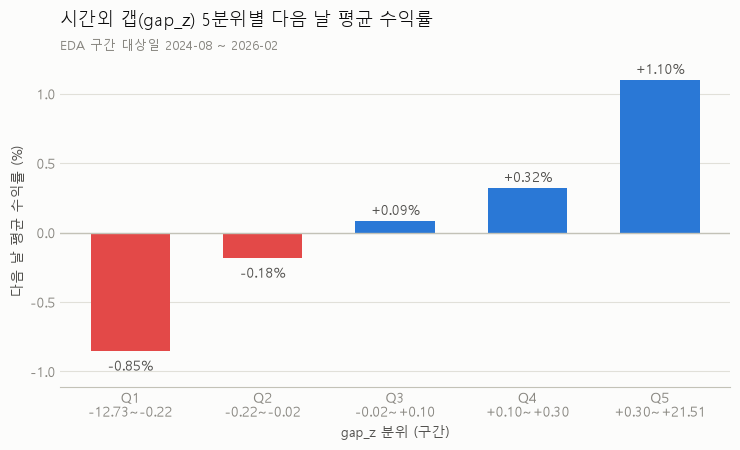

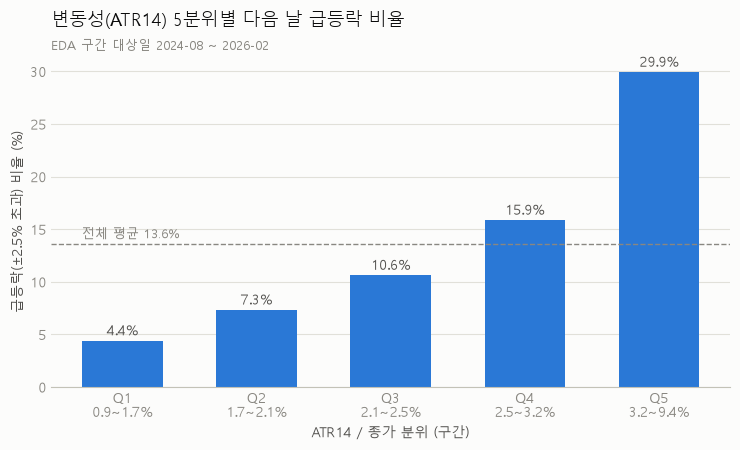

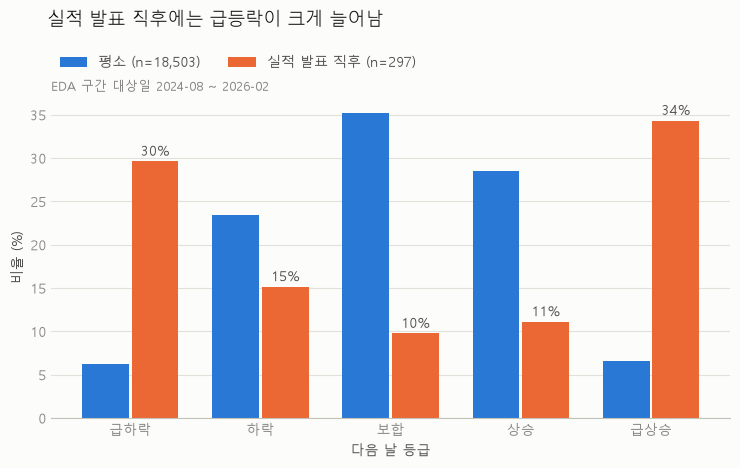

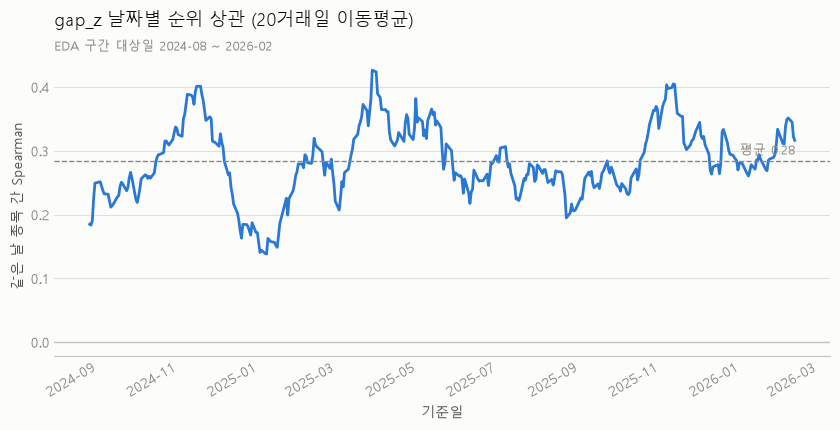

gap_z 구간별 방향 적중률(%): {'-2 이하': 82.7, '-2 ~ -1': 80.6, '-1 ~ -0.3': 65.8, '-0.3 ~ 0.3': 56.3, '0.3 ~ 1': 70.2, '1 ~ 2': 75.2, '2 이상': 90.8}
구간별 비중(%): {'-2 이하': 0.8, '-2 ~ -1': 2.1, '-1 ~ -0.3': 12.4, '-0.3 ~ 0.3': 64.8, '0.3 ~ 1': 16.8, '1 ~ 2': 2.2, '2 이상': 0.8}


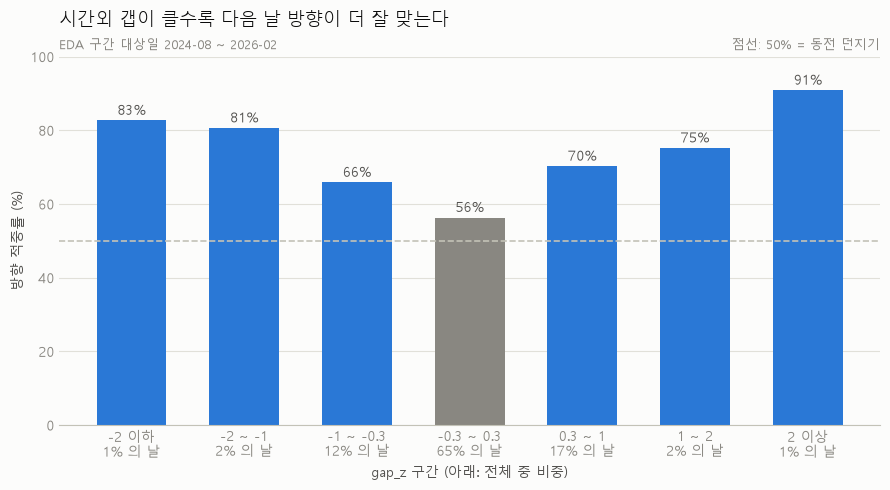

['01_gap_z_quintile.png', '02_atr14_big.png', '03_earnings_label.png', '04_gap_z_ic_time.png', '05_earn_hist.png', '06_symbol_bigmove.png', '07_market_regime.png', '08_coverage.png', '09_gap_z_hit.png']


In [12]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
have = {f.name for f in font_manager.fontManager.ttflist}
plt.rcParams.update({"font.family": next((f for f in ["Malgun Gothic", "AppleGothic", "NanumGothic"] if f in have), "sans-serif"),
                     "axes.unicode_minus": False})
FIGS = ROOT / "work/b/figs"; FIGS.mkdir(exist_ok=True)
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE, RED = "#2a78d6", "#eb6834", "#e34948"
SUB = f"EDA 구간 대상일 {tr.target.min():%Y-%m} ~ {EDA_END:%Y-%m}"

def style(ax, title, xlabel, ylabel, fig):
    ax.set_facecolor(SURFACE); fig.set_facecolor(SURFACE)
    ax.set_title(title, loc="left", color=INK, fontsize=13, pad=22)
    ax.text(0, 1.02, SUB, transform=ax.transAxes, color=MUTED, fontsize=9)
    ax.set_xlabel(xlabel, color=INK2); ax.set_ylabel(ylabel, color=INK2)
    ax.tick_params(colors=MUTED, length=0); ax.grid(axis="y", color=GRID, linewidth=0.8); ax.set_axisbelow(True)
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(AXIS)

def bar_labels(ax, bars, fmt):
    for r in bars:
        h = r.get_height()
        ax.annotate(fmt(h), (r.get_x() + r.get_width() / 2, h), xytext=(0, 4 if h >= 0 else -14),
                    textcoords="offset points", ha="center", color=INK2, fontsize=10)

# 1) gap_z 5분위 → 다음 날 평균 수익률
q = pd.qcut(tr.gap_z, 5, labels=[f"Q{i}" for i in range(1, 6)]); m = tr.groupby(q, observed=True).ret_pct.mean()
lo, hi = tr.groupby(q, observed=True).gap_z.agg(["min", "max"]).T.values
fig, ax = plt.subplots(figsize=(7.5, 4.6))
bars = ax.bar(m.index, m.values, width=0.6, color=[RED if x < 0 else BLUE for x in m.values]); bar_labels(ax, bars, lambda x: f"{x:+.2f}%")
ax.axhline(0, color=AXIS, linewidth=1); ax.set_ylim(min(m.min() * 1.3, -0.1), m.max() * 1.15)
ax.set_xticks(range(5), [f"{k}\n{a:+.2f}~{c:+.2f}" for k, a, c in zip(m.index, lo, hi)])
style(ax, "시간외 갭(gap_z) 5분위별 다음 날 평균 수익률", "gap_z 분위 (구간)", "다음 날 평균 수익률 (%)", fig)
fig.tight_layout(); fig.savefig(FIGS / "01_gap_z_quintile.png", dpi=150); plt.show()

# 2) ATR14 5분위 → 급등락 비율
q = pd.qcut(tr.atr14, 5, labels=[f"Q{i}" for i in range(1, 6)]); bg = tr.groupby(q, observed=True).big.mean() * 100
lo, hi = tr.groupby(q, observed=True).atr14.agg(["min", "max"]).T.values * 100; avg = tr.big.mean() * 100
fig, ax = plt.subplots(figsize=(7.5, 4.6))
bars = ax.bar(bg.index, bg.values, width=0.6, color=BLUE); bar_labels(ax, bars, lambda x: f"{x:.1f}%")
ax.axhline(avg, color=MUTED, linewidth=1, linestyle="--")
ax.annotate(f"전체 평균 {avg:.1f}%", (-0.3, avg), xytext=(0, 4), textcoords="offset points", color=MUTED, fontsize=9)
ax.set_xticks(range(5), [f"{k}\n{a:.1f}~{c:.1f}%" for k, a, c in zip(bg.index, lo, hi)])
style(ax, "변동성(ATR14) 5분위별 다음 날 급등락 비율", "ATR14 / 종가 분위 (구간)", "급등락(±2.5% 초과) 비율 (%)", fig)
fig.tight_layout(); fig.savefig(FIGS / "02_atr14_big.png", dpi=150); plt.show()

# 3) 실적 발표 직후 vs 평소 label 분포
ct = pd.crosstab(tr.earn_now, tr.label, normalize="index") * 100; n = tr.earn_now.value_counts()
fig, ax = plt.subplots(figsize=(7.5, 4.8)); x, w = np.arange(5), 0.36
ax.bar(x - w / 2 - 0.01, ct.loc[0].values, w, color=BLUE, label=f"평소 (n={n[0]:,})")
b1 = ax.bar(x + w / 2 + 0.01, ct.loc[1].values, w, color=ORANGE, label=f"실적 발표 직후 (n={n[1]:,})"); bar_labels(ax, b1, lambda v: f"{v:.0f}%")
ax.set_xticks(x, ["급하락", "하락", "보합", "상승", "급상승"])
style(ax, "", "다음 날 등급", "비율 (%)", fig)
ax.legend(frameon=False, labelcolor=INK2, loc="lower left", bbox_to_anchor=(0, 1.06), ncol=2, borderaxespad=0.2)
fig.tight_layout(rect=(0, 0, 1, 0.92))
fig.text(0.07, 0.965, "실적 발표 직후에는 급등락이 크게 늘어남", color=INK, fontsize=13, va="top")
fig.savefig(FIGS / "03_earnings_label.png", dpi=150); plt.show()

# 4) gap_z 날짜별 IC 20일 이동평균
ic = daily_ic(tr, "gap_z", "ret_pct"); roll = ic.rolling(20, min_periods=10).mean()
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.plot(roll.index, roll.values, color=BLUE, linewidth=2); ax.axhline(0, color=AXIS, linewidth=1)
ax.axhline(ic.mean(), color=MUTED, linewidth=1, linestyle="--")
ax.annotate(f"평균 {ic.mean():.2f}", (roll.index[-1], ic.mean()), xytext=(0, 5), textcoords="offset points", color=MUTED, fontsize=9, ha="right")
style(ax, "gap_z 날짜별 순위 상관 (20거래일 이동평균)", "기준일", "같은 날 종목 간 Spearman", fig)
fig.autofmt_xdate(); fig.tight_layout(); fig.savefig(FIGS / "04_gap_z_ic_time.png", dpi=150); plt.show()
# 9) gap_z 크기별 다음 날 방향 적중률 (gap_z 부호 = 다음 날 수익률 부호)
h = tr[["gap_z", "ret_pct"]].dropna()
h = h[(h.gap_z != 0) & (h.ret_pct != 0)]
edges = [-np.inf, -2, -1, -0.3, 0.3, 1, 2, np.inf]
names = ["-2 이하", "-2 ~ -1", "-1 ~ -0.3", "-0.3 ~ 0.3", "0.3 ~ 1", "1 ~ 2", "2 이상"]
h["bin"] = pd.cut(h.gap_z, edges, labels=names)
hg = h.groupby("bin", observed=True)
hit = hg.apply(lambda g: (np.sign(g.gap_z) == np.sign(g.ret_pct)).mean() * 100, include_groups=False)
cnt = hg.size(); share = cnt / cnt.sum() * 100
print("gap_z 구간별 방향 적중률(%):", hit.round(1).to_dict()); print("구간별 비중(%):", share.round(1).to_dict())
fig, ax = plt.subplots(figsize=(9, 5))
cols = [MUTED if n == "-0.3 ~ 0.3" else BLUE for n in hit.index]
bars = ax.bar(range(len(hit)), hit.values, width=0.62, color=cols)
bar_labels(ax, bars, lambda v: f"{v:.0f}%")
ax.axhline(50, color=AXIS, linewidth=1.2, linestyle="--")
ax.text(1.0, 1.02, "점선: 50% = 동전 던지기", transform=ax.transAxes, color=MUTED, fontsize=9, ha="right")
ax.set_ylim(0, 100)
ax.set_xticks(range(len(hit)), [f"{n}\n{s:.0f}% 의 날" for n, s in zip(hit.index, share.values)])
style(ax, "시간외 갭이 클수록 다음 날 방향이 더 잘 맞는다", "gap_z 구간 (아래: 전체 중 비중)", "방향 적중률 (%)", fig)
fig.tight_layout(); fig.savefig(FIGS / "09_gap_z_hit.png", dpi=150); plt.show()
print(sorted(p.name for p in FIGS.glob("*.png")))